# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer: 1860604
- Naam: Hidde van Weerlee
- Datum:03-3-2026

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [98]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE
import sklearn
from PIL import Image

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [34]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.687935,1.270394,0.041218,1.072872,1.522411,6.219299,0.517217,3.014126,1.272619,1.262694,1.050958,1.259469,1.039144,1.282377,0.740414,"""Crime (3rd person)"""
1.309192,1.074454,0.915276,0.717143,0.871633,6.068165,0.613425,0.718053,0.45939,1.151622,0.465783,0.626049,0.783746,0.519572,0.503133,"""Romance (1st person)"""
1.045882,1.082274,1.218269,1.15993,0.277818,6.107947,0.852787,0.640925,0.384645,1.486211,0.16668,0.482857,0.766636,0.676403,0.207206,"""Romance (1st person)"""
0.962823,0.946491,0.896993,1.230937,0.792755,5.277812,1.332768,2.082402,0.384911,1.450092,1.085553,0.603619,1.477301,1.30571,0.671362,"""Romance (3rd person)"""
1.596865,0.442587,0.481486,0.899423,0.442869,4.660116,0.229388,2.330609,0.832029,1.468023,0.85999,0.337767,0.415366,0.776571,0.635415,"""Crime (1st person)"""


In [9]:
print(data.shape)

(200, 16)


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.

m = alle datapunten
n = aantal features
n' = aantal features na reductie

0. (m,n) = (200,15)
1. (1,n) = (1, 15)
2. Vergelijkt alle paren (n,n) = (15,15)
3. 1 vector per feature = (n,n) = (15,15) 
en er is 1 waarde per eigenvector dus (n,1) = (15,1)
4. (n,n')
5. (m,n) x (n, n') = (m,n')

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [88]:
def compute_pca(X, n_components, minimum_information=False):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)

    mean = np.mean(arr, axis=0)
    centered = arr - mean

    covariantiematrix = np.cov(centered, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eig(covariantiematrix)

    sorted_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_idx]
    eigenvectors = eigenvectors[:, sorted_idx]

    variance_ratio = eigenvalues / np.sum(eigenvalues)
    if minimum_information != False:
        explained_variance = np.sum(variance_ratio[:n_components])
        while explained_variance < minimum_information:
            n_components += 1
            explained_variance = np.sum(variance_ratio[:n_components])
    
    else:
        explained_variance = np.sum(variance_ratio[:n_components])
        
    print(f"Variance explained by {n_components} components:", explained_variance)

    n_eigenvectors = eigenvectors[:, :n_components]

    # Stap 5.
    return centered @ n_eigenvectors

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [89]:
np.random.seed(1)
X = np.random.rand(3, 10)
X_reduced = compute_pca(X, n_components=2)
print(X_reduced)
print(X_reduced.shape)

Variance explained by 2 components: (0.9999999999999998+0j)
[[ 0.434+0.j -0.498+0.j]
 [ 0.421+0.j  0.504+0.j]
 [-0.855+0.j -0.005+0.j]]
(3, 2)


### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

Variance explained by 2 components: 0.6866656218830466


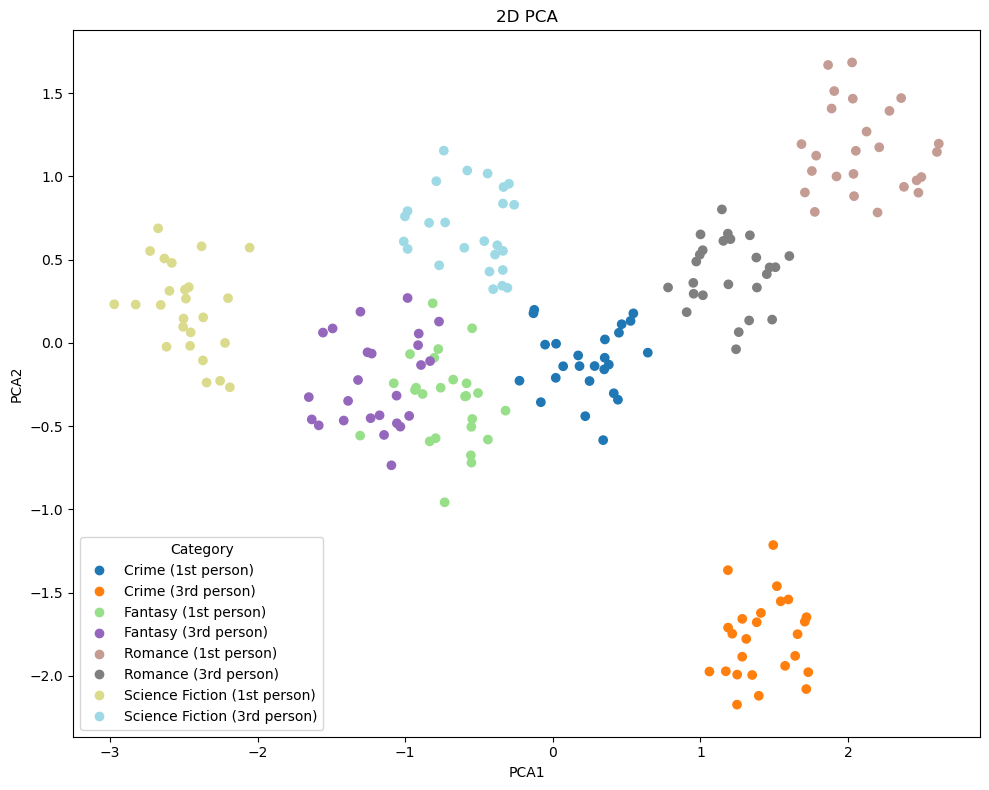

In [90]:
data_pd = data.to_pandas()
X = data_pd.iloc[:, :-1].to_numpy()
labels = data_pd.iloc[:, -1]

TWOD_data = compute_pca(X, n_components=2)

labels_encoded = pd.Categorical(labels).codes

plt.figure(figsize=(10,8))
scatter_plot = plt.scatter(TWOD_data[:,0],TWOD_data[:,1],c=labels_encoded,cmap="tab20")

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("2D PCA")

handles, _ = scatter_plot.legend_elements()
plt.legend(handles, pd.Categorical(labels).categories, title="Category")


plt.tight_layout()
plt.show()

Variance explained by 3 components: 0.7721763602652282


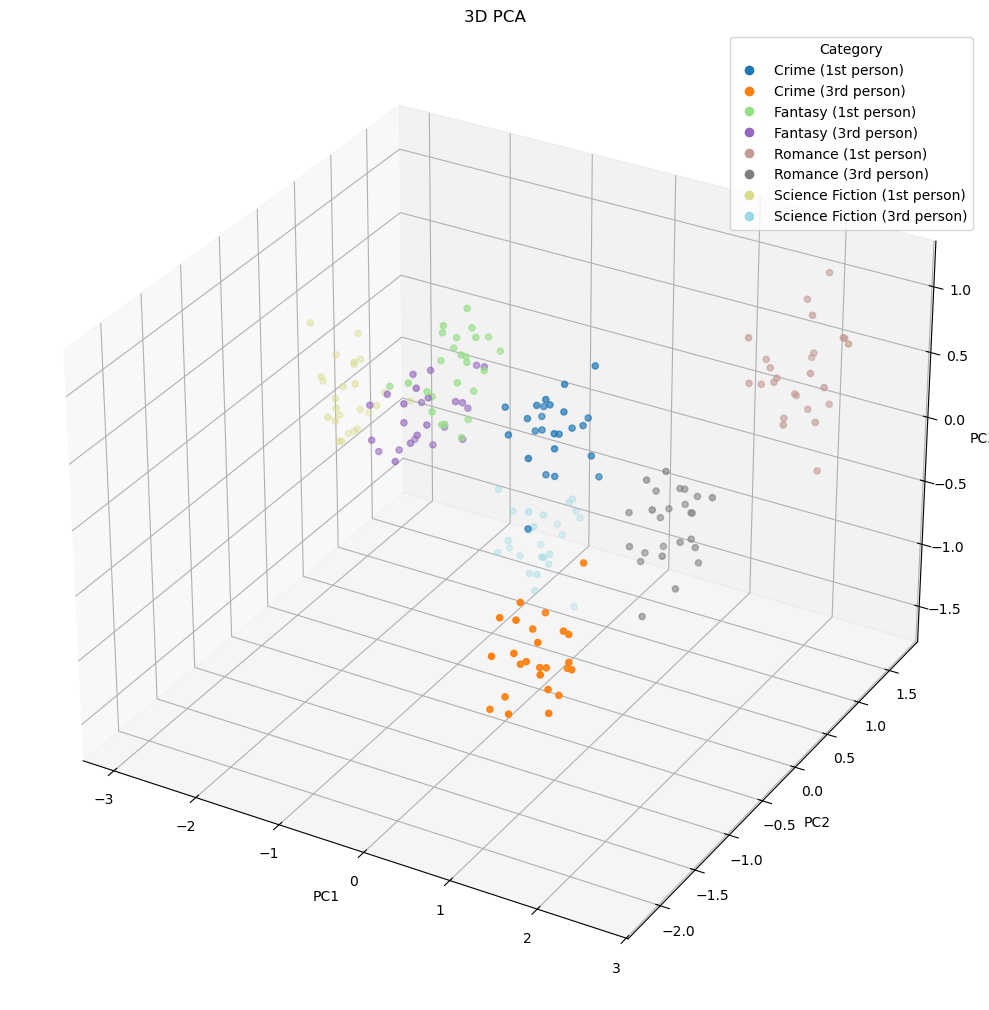

In [91]:
data_pd = data.to_pandas()
X = data_pd.iloc[:, :-1].to_numpy()
labels = data_pd.iloc[:, -1]

ThreeD_data = compute_pca(X, n_components=3)

labels_encoded = pd.Categorical(labels).codes

fig = plt.figure(figsize=(10,12))
ax = fig.add_subplot(projection='3d')  

scatter = ax.scatter(ThreeD_data[:,0],ThreeD_data[:,1],ThreeD_data[:,2],c=labels_encoded,cmap="tab20")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA")

handles, _ = scatter.legend_elements()
plt.legend(handles,pd.Categorical(labels).categories,title="Category")

plt.tight_layout()
plt.show()

### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 

Te onderscheiden zijn: Crime 3rd person en 1st,  romance 1st en romance 3rd, science fiction 1st, Science fiction 3rd,

niet te onderscheiden: Fantasy 1st en fantasy 3rd

2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.

3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

De code hieronder geeft aan hoeveel dimensies er moeten zijn voor het houden van een minimale hoeveelheid informatie door gebruik te maken van de feature minimum_information

In [92]:
data_pd = data.to_pandas()
X = data_pd.iloc[:, :-1].to_numpy()
compute_pca(X, n_components=3,minimum_information=0.90)

Variance explained by 7 components: 0.9049017075553294


array([[-0.547,  0.087,  0.712, ...,  0.184,  0.012,  0.27 ],
       [-0.555, -0.675,  0.499, ...,  0.547, -0.263,  0.064],
       [-0.587, -0.319,  0.368, ...,  0.712,  0.276,  0.075],
       ...,
       [ 1.395, -2.119, -0.605, ...,  0.072,  0.078, -0.522],
       [ 1.573, -1.939, -0.123, ..., -0.234, -0.023, -0.164],
       [ 1.658, -1.749, -0.599, ..., -0.315,  0.261, -0.072]],
      shape=(200, 7))

In [93]:
compute_pca(X, n_components=3,minimum_information=0.95)

Variance explained by 11 components: 0.9616681690332413


array([[-0.547,  0.087,  0.712, ..., -0.351,  0.118, -0.224],
       [-0.555, -0.675,  0.499, ..., -0.093, -0.057,  0.148],
       [-0.587, -0.319,  0.368, ..., -0.024,  0.265,  0.248],
       ...,
       [ 1.395, -2.119, -0.605, ...,  0.11 , -0.071, -0.307],
       [ 1.573, -1.939, -0.123, ...,  0.162, -0.037,  0.001],
       [ 1.658, -1.749, -0.599, ..., -0.022, -0.207, -0.349]],
      shape=(200, 11))

1. 
Te onderscheiden zijn: Crime 3rd person en 1st,  romance 1st en romance 3rd, science fiction 1st, Science fiction 3rd,

niet te onderscheiden: Fantasy 1st en fantasy 3rd

2. 
Bij 2D: 0.6866656218830466%
Bij 3D: 0.7721763602652282


3. 7 dimensies want dat zie je in de code hierboven geschreven


4. 11 dimensies want dat zie je in de code hierboven geschreven

## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien). 

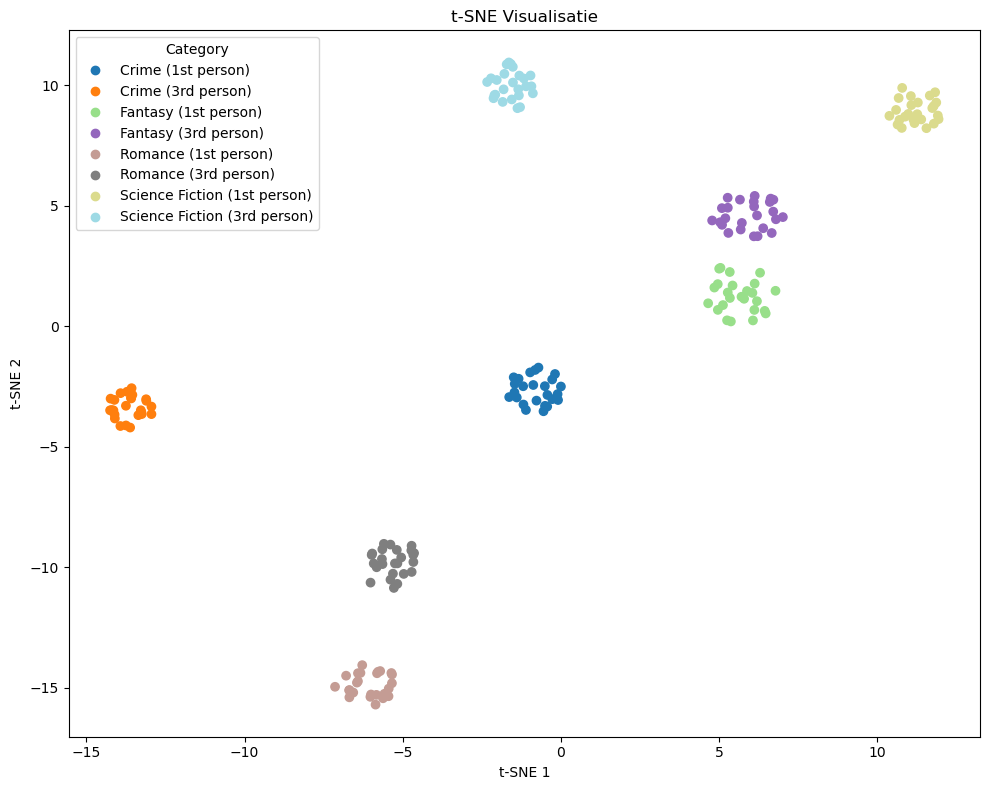

In [97]:
data_pd = data.to_pandas()

X = data_pd.iloc[:, :-1].to_numpy()
labels = data_pd.iloc[:, -1].to_numpy()

tsne = TSNE(n_components=2, random_state=42)

X_tsne = tsne.fit_transform(X)

labels_encoded = pd.Categorical(labels).codes

plt.figure(figsize=(10,8))

scatter = plt.scatter(X_tsne[:,0],X_tsne[:,1],c=labels_encoded,cmap="tab20")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualisatie")

handles, _ = scatter.legend_elements()
plt.legend(handles,pd.Categorical(labels).categories,title="Category")

plt.tight_layout()
plt.show()

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?
2. Hoe verhouden de algoritmes zich in het behoud van informatie?

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

1. 
t-SNE is veel beter en zien we dat de categorieen meer van elkaar af zijn en makkelijker te onderscheiden zijn.

2. PCA behoud zo veel mogelijk op hoe de data als geheeld zich verspreidt. en t-SNE meer op locale structuur dus clusters bij elkaar zetten en beheid de vorm van de data.

3. PCA: Als je globale patronen wilt analyseren of als de structuur onbekend is. Als het lineare verbanden hebben.
t-SNE: Als cluster belangrijk zijn en niet lineare is

4. lineair gestructureede data

5. Cluster visualisaties, image embedding

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
    
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

In [105]:
img = Image.open("IMG_1010_Veh_4.JPG")
img_array = np.array(img)

breedte, lengte = img.size

print("Breedte:", breedte)
print("Lengte:", lengte)

dimensies = breedte * lengte * 3
print("hoeveel dimensies:", dimensies)
print("shape of image:", img_array.shape)

Breedte: 2592
Lengte: 1944
hoeveel dimensies: 15116544
shape of image: (1944, 2592, 3)


1. Ik heb foto's dus het zou moeten zijn de lengte x breede van de pixels in de foto's x 3 omdat het kleur fotos zijn. dus (lengte x breedte x 3). is dus. 1944 x 2592 x 3 = 15116544

2. Kan helpen om ruis te verminderen door overbodige informatie te verwijderen. Kan tijd besparen zodat je niet door alle dimensies heen hoeft te gaan. Kan patronen hetkennen.